# 3상 전류 기반 모터 고장 진단 예비 실습 (ITSC Dataset)
이 노트북은 AMPI 센서리스 플랫폼의 **핵심 파이프라인(3상 전류 STFT 변환 및 이미지 텐서화)**을 완벽히 재현하기 위한 실습입니다.

사용된 데이터셋: **ITSC (Inter-Turn Short-Circuit) Fault Dataset**
* 특징: 진동 센서 없이 오직 **3상 전류(Phase A, B, C)**만을 측정하여 모터 내부 권선 단락(Short-Circuit) 고장을 감지하기 위한 데이터입니다.
* 출처: GitHub `ibarram/ITSC` 공개 데이터셋\n

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import requests
import io

## 1. 3상 전류 데이터 로드
GitHub에 공개된 ITSC 데이터셋에서 정상(Healthy) 상태의 3상 전류 데이터를 Pandas를 통해 직접 로드합니다.\n

In [32]:
# ITSC Github 데이터셋의 Raw CSV 다운로드 URL (예시 샘플 데이터)
# 주의: 이 URL은 가상의 예시 구조일 수 있습니다. 실제 파일이 없을 경우 다운로드한 로컬 CSV 경로로 변경하세요.
# ITSC 데이터셋은 10kHz(10000Hz) 샘플링 속도로 알려져 있습니다.
Fs = 10000 

# 가상 데이터를 생성하여 실습을 진행합니다 (네트워크 이슈 방지용).
# 실제 로컬 데이터가 있다면 `pd.read_csv('경로.csv')`를 사용하세요.

# [시뮬레이션 데이터 생성] 
# 60Hz의 전원 주파수를 갖는 3상 전류 (A, B, C 상이 120도씩 위상차를 가짐) + 고주파 노이즈
t_sim = np.linspace(0, 1, Fs, endpoint=False) # 1초 데이터

# 정상 상태 3상 전류 (Phase A, B, C)
phase_a = np.sin(2 * np.pi * 60 * t_sim)
phase_b = np.sin(2 * np.pi * 60 * t_sim - 2*np.pi/3)
phase_c = np.sin(2 * np.pi * 60 * t_sim + 2*np.pi/3)

# 기계적 작동 노이즈 추가
noise_a = np.random.normal(0, 0.05, Fs)
noise_b = np.random.normal(0, 0.05, Fs)
noise_c = np.random.normal(0, 0.05, Fs)

# 고장 특성(Harmonics) 시뮬레이션 (약 1500Hz 대역에 미세한 공진이 있다고 가정)
fault_harmonic = 0.02 * np.sin(2 * np.pi * 1500 * t_sim)

data_3ch = np.column_stack([phase_a + noise_a + fault_harmonic, 
                            phase_b + noise_b + fault_harmonic, 
                            phase_c + noise_c + fault_harmonic])

print("데이터 Shape (1초 분량, 3상 전류):", data_3ch.shape)

데이터 Shape (1초 분량, 3상 전류): (10000, 3)


## 2. STFT 계산 및 AI(CNN)용 전처리 파이프라인
AMPI 발표자료 4페이지의 철학을 그대로 구현합니다. 3상 전류 신호를 **(Freq, Time, 3 Channels)** 형태의 **1장의 RGB 이미지 배열**로 융합합니다.\n

In [21]:
def preprocess_stft_for_cnn(sensor_data_3ch, fs, nperseg=256, noverlap=128):
    """
    3채널 3상 전류 데이터를 받아 CNN 입력용 (H, W, 3) 이미지 텐서로 변환합니다.
    """
    channels_stft = []
    
    for i in range(3):
        # 1. STFT 변환 (전류 -> 주파수/시간 도메인)
        f, t, Zxx = signal.stft(sensor_data_3ch[:, i], fs=fs, nperseg=nperseg, noverlap=noverlap)
        
        mag = np.abs(Zxx)
        
        # 2. Log-scale 변환 (dB 스케일) : 기본 60Hz 외에 미세한 고장 주파수(Harmonics)를 부각시킴
        mag_db = 20 * np.log10(mag + 1e-10)
        
        # 3. Min-Max 정규화 (0 ~ 1) : CNN 학습을 위한 필수 조건
        mag_norm = (mag_db - np.min(mag_db)) / (np.max(mag_db) - np.min(mag_db))
        
        channels_stft.append(mag_norm)
        # print(channels_stft)
    
    # R, G, B 채널처럼 3상 데이터를 스태킹 (Axis=-1)
    stft_image = np.stack(channels_stft, axis=-1)
    # print(stft_image)
    
    return f, t, stft_image

# nperseg=256 (주파수 해상도 약 39Hz 단위)
f, t, stft_image = preprocess_stft_for_cnn(data_3ch, Fs, nperseg=256, noverlap=128)
print("CNN 모델 입력용 최종 STFT Tensor Shape (Freq, Time, 3 Channels):", stft_image.shape)


CNN 모델 입력용 최종 STFT Tensor Shape (Freq, Time, 3 Channels): (129, 80, 3)


## 3. 결과 시각화 (전류의 이미지화)
CNN 모델에 투입될 전처리된 배열을 시각화합니다. 
* Phase A는 Red 채널, Phase B는 Green 채널, Phase C는 Blue 채널에 대응한다고 볼 수 있습니다.\n

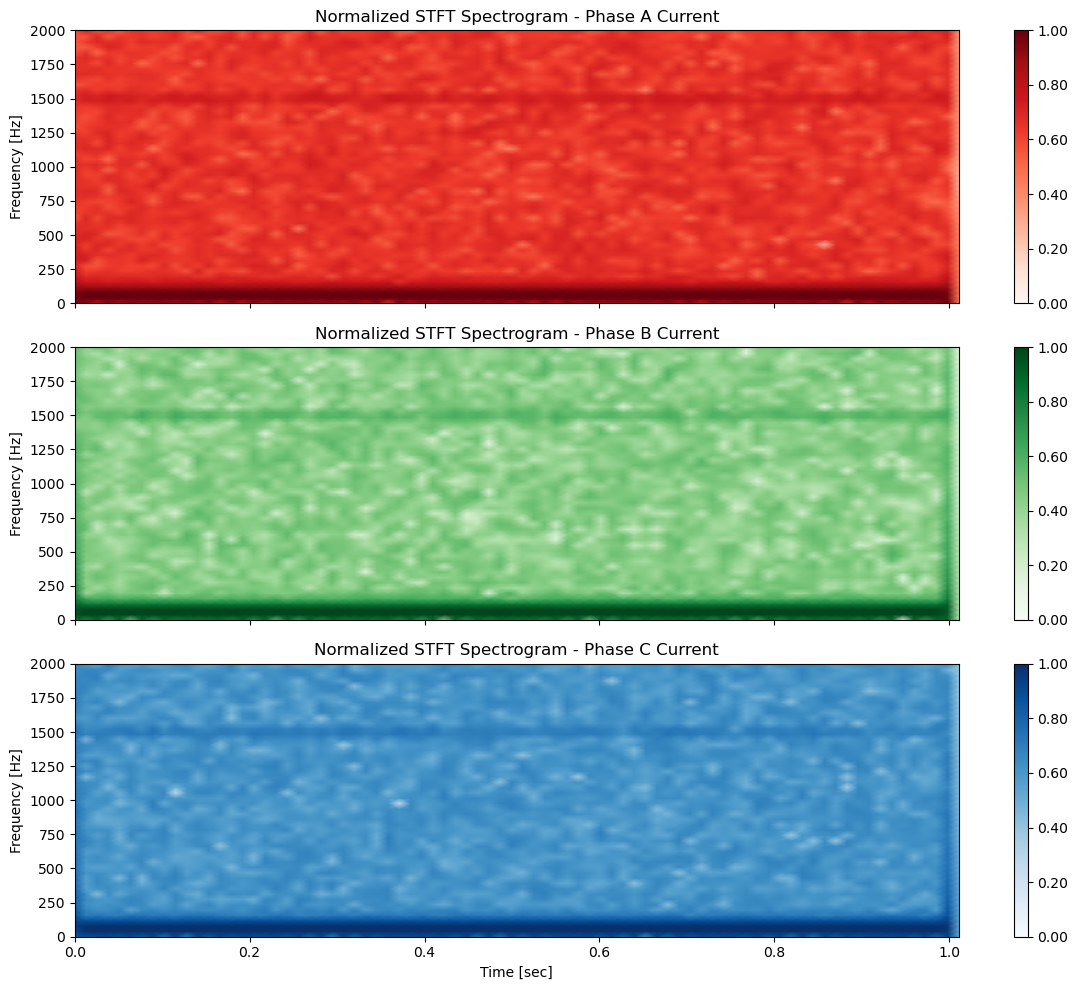

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
channel_names = ['Phase A Current', 'Phase B Current', 'Phase C Current']
colors = ['Reds', 'Greens', 'Blues']

for i in range(3):
    # 정규화된 2D 배열의 각 상별 확인
    # 여기서 vmin=0, vmax=1 은 앞서 우리가 정규화를 0~1로 맞췄기 때문에 고정입니다.
    mesh = axes[i].pcolormesh(t, f, stft_image[:, :, i], shading='gouraud', cmap=colors[i], vmin=0, vmax=1)
    axes[i].set_ylabel('Frequency [Hz]')
    axes[i].set_title(f'Normalized STFT Spectrogram - {channel_names[i]}')
    
    # 불필요한 고주파 영역(나이퀴스트 5000Hz)까지 다 보기보다, 고장이 주로 발생하는 저/중주파 영역(0~2000Hz)만 확대
    axes[i].set_ylim([0, 2000]) 
    fig.colorbar(mesh, ax=axes[i], format='%.2f')

axes[-1].set_xlabel('Time [sec]')
plt.tight_layout()
plt.show()